# 🔮 PriceOracle — AI Dynamic Pricing & Profit Intelligence
## ML Model Pipeline: Data → EDA → Training → Export

**System:** Predict demand → Simulate prices → Optimize profit → Explain with AI  
**Target:** `quantity` (demand) driven by price, competition, season, and product features  
**Author:** PriceOracle ML Engine v1.0

---
### 📋 Pipeline Overview
1. Data Loading & Validation
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Model Training (Random Forest + XGBoost + Gradient Boosting)
5. Model Evaluation & Comparison
6. Optimization Engine
7. Export Artifacts (`.pkl` files)

---
## 🔧 0. Install & Import Libraries

In [ ]:
# Install required libraries (run once)
# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib openpyxl

In [2]:
%pip install  xgboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 259.2 kB/s eta 0:06:33
   ---------------------------------------- 0.0/101.7 MB 279.3 kB/s eta 0:06:04
   ---------------------------------------- 0.1/101.7 MB 476.3 kB/s eta 0:03:34
   ---------------------------------------- 0.4/101.7 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 0.7/101.7 MB 2.6 MB/s eta 0:00:39
   ---------------------------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os
import json

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Run: pip install xgboost")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Output directory for model artifacts
os.makedirs('model_artifacts', exist_ok=True)
print("✅ All libraries loaded successfully")
print(f"   XGBoost available: {XGBOOST_AVAILABLE}")

✅ All libraries loaded successfully
   XGBoost available: True


---
## 📂 1. Data Loading & Validation

In [6]:
# ─── Load Dataset ──────────────────────────────────────────────────────────────
# Update path to your file location
DATA_PATH = 'Amazon_Sales_Data.csv'   # or .csv

if DATA_PATH.endswith('.xlsx'):
    df = pd.read_excel(DATA_PATH, sheet_name='Cleaned_Data')
else:
    df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

✅ Dataset loaded: 113,815 rows × 18 columns


,product_id,category,size,region,date,price,quantity,cost_price,competitor_price,price_diff,price_ratio,discount_pct,is_discount,day_of_week,month,is_festive_season,revenue,profit
0,JNE3000-KR-XL,Kurta,XL,GUJARAT,2022-07-14,1199,3,802.22,1273,-74,0.9419,0.0,0,4,7,0,3597,1190.34
1,JNE3001-KR-M,Kurta,M,DELHI,2022-12-05,599,8,398.00,539,60,1.1113,6.0,1,1,12,0,4792,1608.00
2,SET3002-ST-L,Set,L,UTTAR PRADESH,2022-10-25,599,6,415.45,592,7,1.0118,18.8,1,2,10,1,3594,1101.30


In [7]:
# ─── Data Quality Report ──────────────────────────────────────────────────────
print("="*60)
print("📊 DATA QUALITY REPORT")
print("="*60)
print(f"Rows:           {df.shape[0]:,}")
print(f"Columns:        {df.shape[1]}")
print(f"Null values:    {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Column dtypes:")
print(df.dtypes.to_string())
print()
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  None ✅")

📊 DATA QUALITY REPORT
Rows:           113,815
Columns:        18
Null values:    0
Duplicate rows: 0

Column dtypes:
product_id            object
category              object
size                  object
region                object
date                  object
price                  int64
quantity               int64
cost_price           float64
competitor_price       int64
price_diff             int64
price_ratio          float64
discount_pct         float64
is_discount            int64
day_of_week            int64
month                  int64
is_festive_season      int64
revenue                int64
profit               float64

Missing values per column:
  None ✅


In [8]:
# ─── Basic Statistics ─────────────────────────────────────────────────────────
print("📈 Numerical Summary:")
df[['price', 'quantity', 'cost_price', 'competitor_price', 
    'discount_pct', 'price_ratio', 'revenue', 'profit']].describe().round(2)

📈 Numerical Summary:


,price,quantity,cost_price,competitor_price,discount_pct,price_ratio,revenue,profit
count,113815.00,113815.00,113815.00,113815.00,113815.00,113815.00,113815.00,113815.00
mean,972.72,5.95,607.78,991.09,18.78,1.00,4172.71,1564.95
std,454.87,4.54,287.86,478.06,16.74,0.13,1347.82,539.37
min,199.00,1.00,109.46,138.00,0.00,0.77,1199.00,359.91
25%,599.00,3.00,391.96,625.00,0.00,0.89,3297.00,1187.31
50%,899.00,5.00,550.63,898.00,17.00,0.98,3996.00,1511.80
75%,1199.00,8.00,760.44,1259.00,33.60,1.09,4990.00,1898.27
max,2598.00,20.00,1817.60,3117.00,50.00,1.44,9481.00,4242.51


In [9]:
# ─── Parse Date ───────────────────────────────────────────────────────────────
df['date'] = pd.to_datetime(df['date'])
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Days covered: {(df['date'].max() - df['date'].min()).days + 1}")

# Derive additional time features
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter']      = df['date'].dt.quarter
df['is_weekend']   = (df['date'].dt.dayofweek >= 5).astype(int)

# Profit margin %
df['profit_margin_pct'] = ((df['price'] - df['cost_price']) / df['price'] * 100).round(2)

# Price tier
df['price_tier'] = pd.cut(df['price'],
                           bins=[0, 400, 800, float('inf')],
                           labels=['Budget', 'Mid-range', 'Premium'])

print(f"\n✅ Added: week_of_year, quarter, is_weekend, profit_margin_pct, price_tier")
print(f"Final shape: {df.shape}")

Date range: 2022-01-01 → 2022-12-31
Days covered: 365

✅ Added: week_of_year, quarter, is_weekend, profit_margin_pct, price_tier
Final shape: (113815, 23)


---
## 🔍 2. Exploratory Data Analysis (EDA)

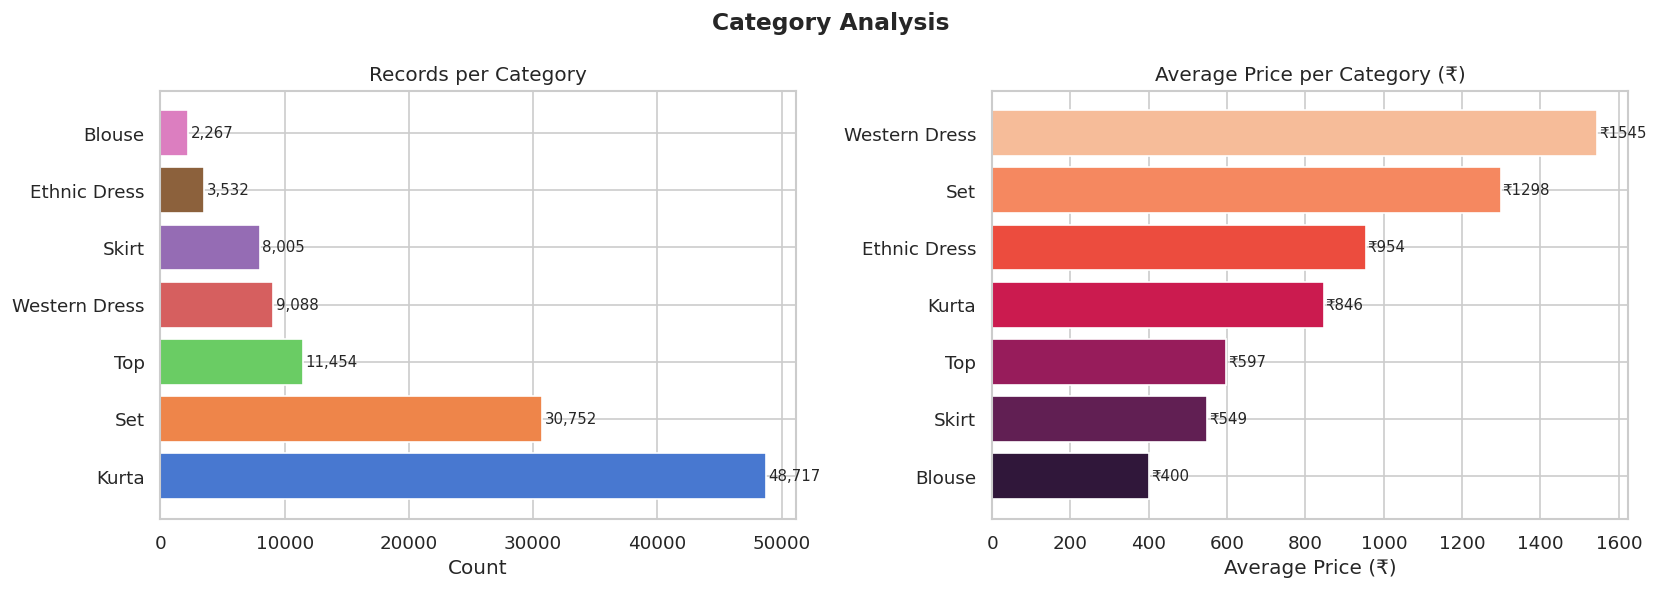

In [10]:
# ─── 2.1 Category Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Category Analysis', fontsize=14, fontweight='bold')

cat_counts = df['category'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color=sns.color_palette('muted', len(cat_counts)))
axes[0].set_title('Records per Category')
axes[0].set_xlabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

cat_avg_price = df.groupby('category')['price'].mean().sort_values()
axes[1].barh(cat_avg_price.index, cat_avg_price.values, color=sns.color_palette('rocket', len(cat_avg_price)))
axes[1].set_title('Average Price per Category (₹)')
axes[1].set_xlabel('Average Price (₹)')
for i, v in enumerate(cat_avg_price.values):
    axes[1].text(v + 5, i, f'₹{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_artifacts/eda_category.png', bbox_inches='tight')
plt.show()

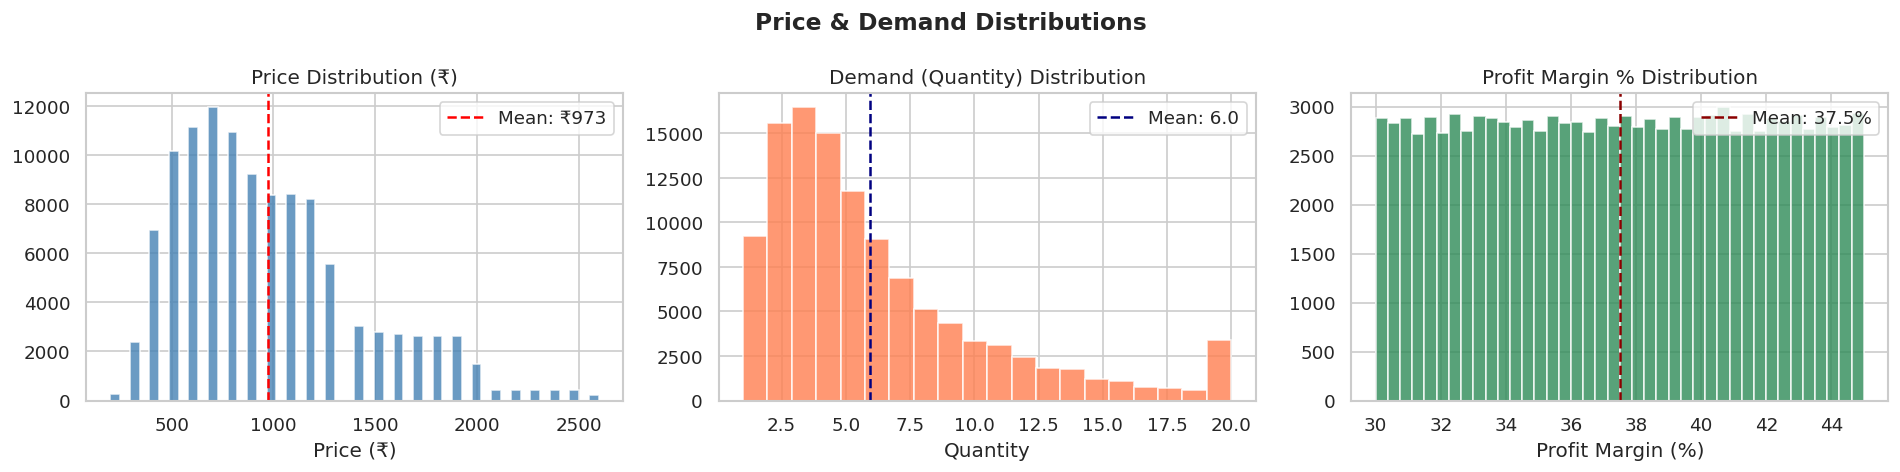

In [11]:
# ─── 2.2 Price Distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Price & Demand Distributions', fontsize=14, fontweight='bold')

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Price Distribution (₹)')
axes[0].set_xlabel('Price (₹)')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f"Mean: ₹{df['price'].mean():.0f}")
axes[0].legend()

axes[1].hist(df['quantity'], bins=20, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Demand (Quantity) Distribution')
axes[1].set_xlabel('Quantity')
axes[1].axvline(df['quantity'].mean(), color='navy', linestyle='--', label=f"Mean: {df['quantity'].mean():.1f}")
axes[1].legend()

axes[2].hist(df['profit_margin_pct'], bins=40, color='seagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('Profit Margin % Distribution')
axes[2].set_xlabel('Profit Margin (%)')
axes[2].axvline(df['profit_margin_pct'].mean(), color='darkred', linestyle='--',
                label=f"Mean: {df['profit_margin_pct'].mean():.1f}%")
axes[2].legend()

plt.tight_layout()
plt.savefig('model_artifacts/eda_distributions.png', bbox_inches='tight')
plt.show()

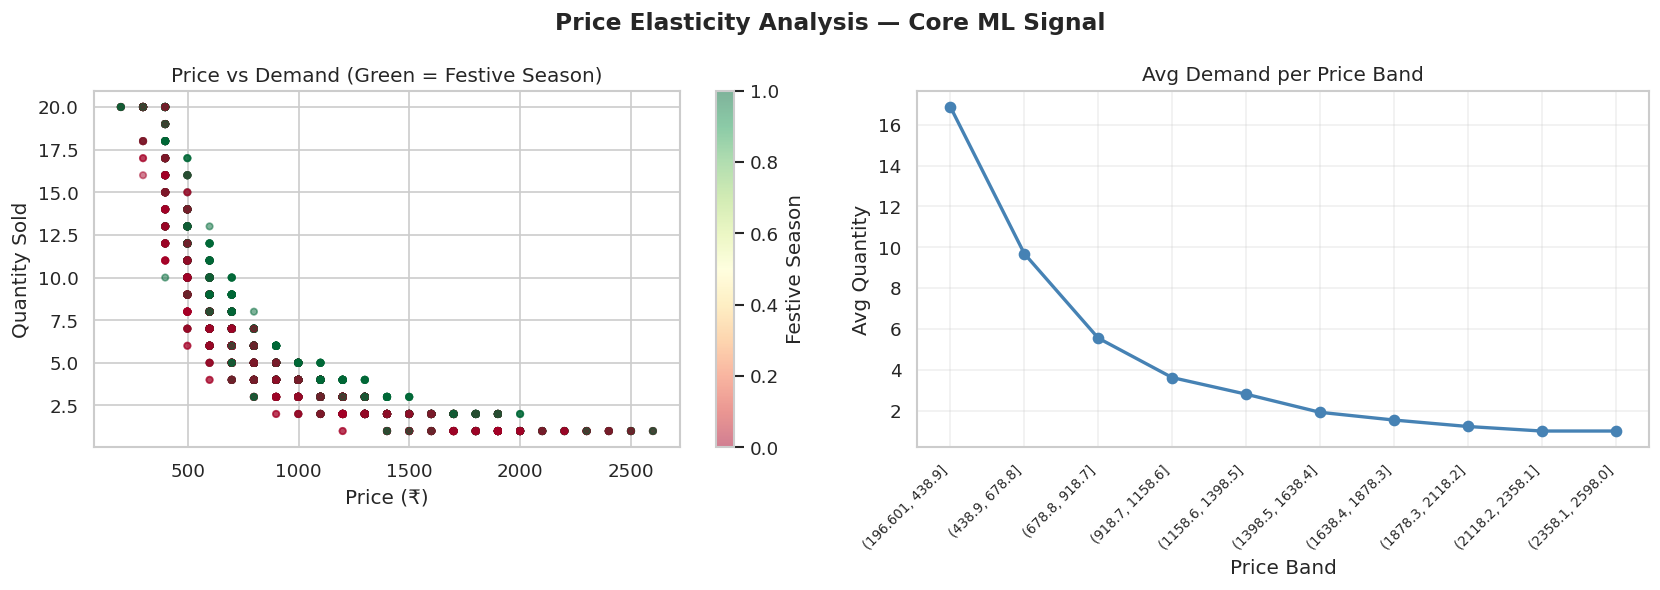

In [12]:
# ─── 2.3 Price Elasticity (Key Insight) ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Elasticity Analysis — Core ML Signal', fontsize=14, fontweight='bold')

# Scatter: price vs quantity
sample = df.sample(3000, random_state=42)
scatter = axes[0].scatter(sample['price'], sample['quantity'],
                           c=sample['is_festive_season'],
                           cmap='RdYlGn', alpha=0.5, s=15)
axes[0].set_title('Price vs Demand (Green = Festive Season)')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Quantity Sold')
plt.colorbar(scatter, ax=axes[0], label='Festive Season')

# Price bin vs avg quantity
df['price_bin'] = pd.cut(df['price'], bins=10)
bin_avg = df.groupby('price_bin')['quantity'].mean()
axes[1].plot(range(len(bin_avg)), bin_avg.values, marker='o', color='steelblue', linewidth=2)
axes[1].set_xticks(range(len(bin_avg)))
axes[1].set_xticklabels([str(b) for b in bin_avg.index], rotation=45, ha='right', fontsize=8)
axes[1].set_title('Avg Demand per Price Band')
axes[1].set_xlabel('Price Band')
axes[1].set_ylabel('Avg Quantity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_artifacts/eda_elasticity.png', bbox_inches='tight')
plt.show()
df.drop(columns=['price_bin'], inplace=True)

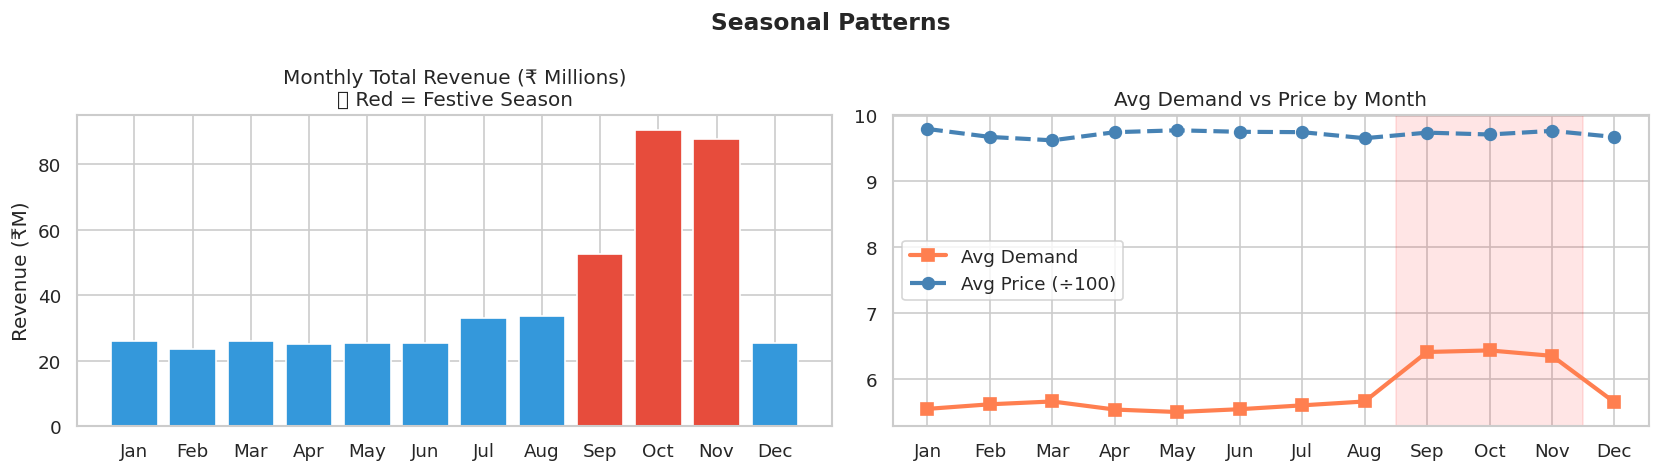

In [13]:
# ─── 2.4 Seasonal Revenue Pattern ────────────────────────────────────────────
monthly = df.groupby('month').agg(
    avg_price   = ('price', 'mean'),
    total_revenue = ('revenue', 'sum'),
    avg_quantity  = ('quantity', 'mean')
).reset_index()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Seasonal Patterns', fontsize=14, fontweight='bold')

color = ['#e74c3c' if m in [9,10,11] else '#3498db' for m in monthly['month']]
axes[0].bar(monthly['month'], monthly['total_revenue']/1e6, color=color, edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_labels)
axes[0].set_title('Monthly Total Revenue (₹ Millions)\n🔴 Red = Festive Season')
axes[0].set_ylabel('Revenue (₹M)')

axes[1].plot(monthly['month'], monthly['avg_quantity'], marker='s', color='coral',
             linewidth=2.5, markersize=7, label='Avg Demand')
axes[1].plot(monthly['month'], monthly['avg_price']/100, marker='o', color='steelblue',
             linewidth=2.5, markersize=7, linestyle='--', label='Avg Price (÷100)')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title('Avg Demand vs Price by Month')
axes[1].legend()
axes[1].axvspan(8.5, 11.5, alpha=0.1, color='red', label='Festive')

plt.tight_layout()
plt.savefig('model_artifacts/eda_seasonal.png', bbox_inches='tight')
plt.show()

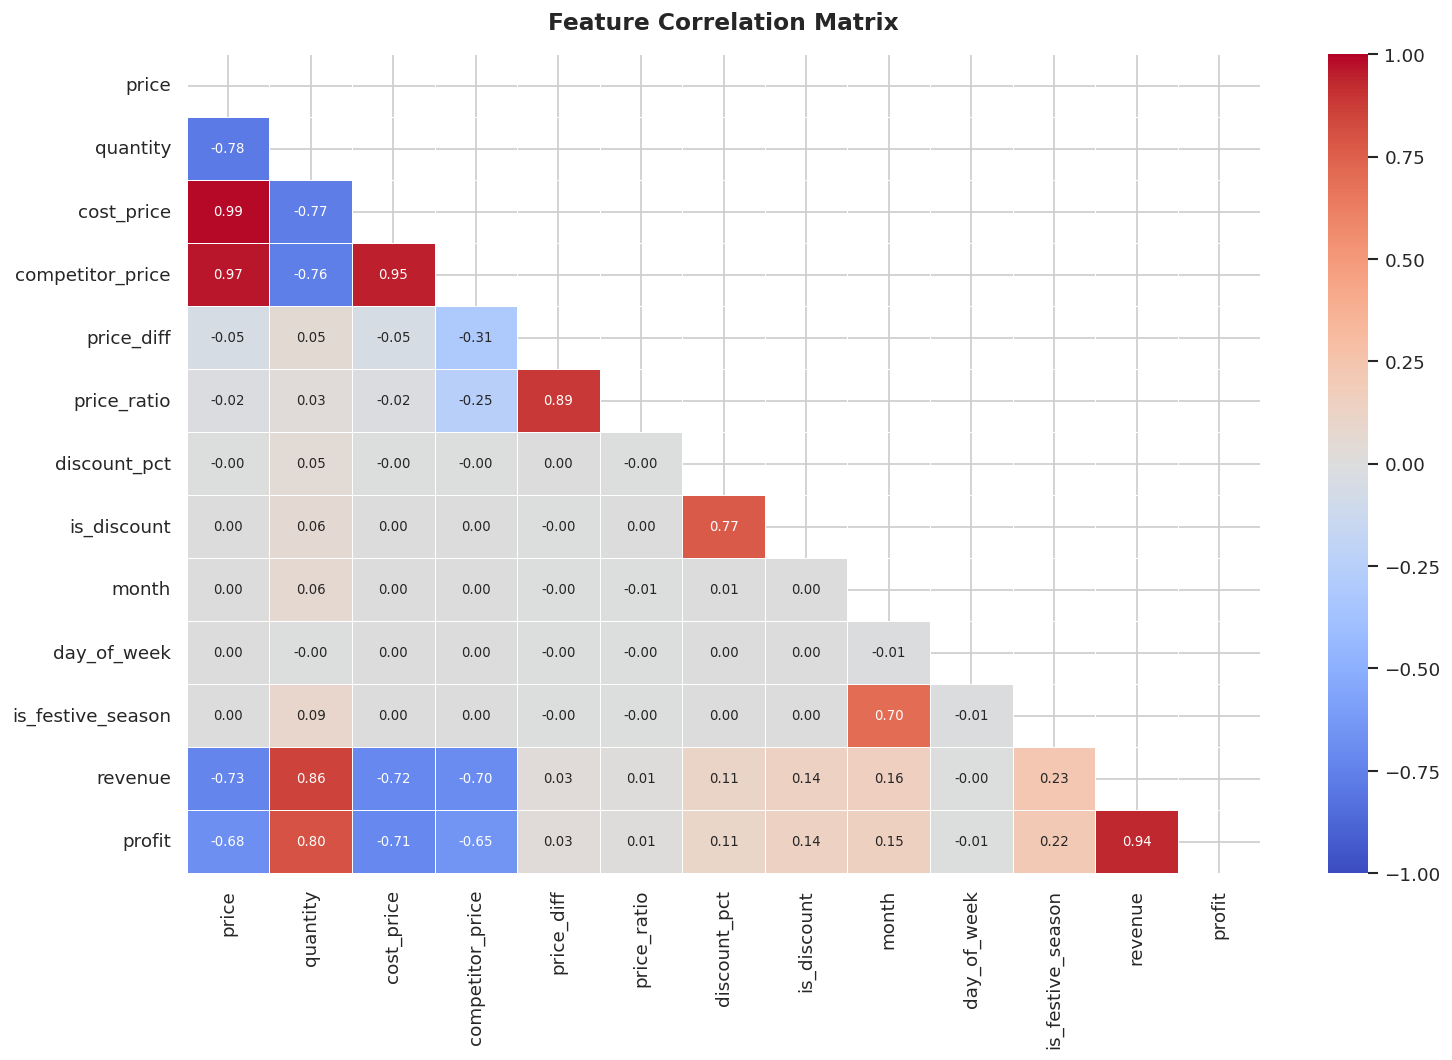


📊 Top correlations with quantity (demand):
revenue              0.856
profit               0.801
price               -0.783
cost_price          -0.773
competitor_price    -0.758
is_festive_season    0.088
month                0.063
is_discount          0.057
price_diff           0.048
discount_pct         0.047
price_ratio          0.030
day_of_week         -0.003


In [14]:
# ─── 2.5 Correlation Heatmap ──────────────────────────────────────────────────
num_cols = ['price', 'quantity', 'cost_price', 'competitor_price',
            'price_diff', 'price_ratio', 'discount_pct', 'is_discount',
            'month', 'day_of_week', 'is_festive_season', 'revenue', 'profit']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('model_artifacts/eda_correlation.png', bbox_inches='tight')
plt.show()

# Top correlations with quantity (target)
print("\n📊 Top correlations with quantity (demand):")
qty_corr = corr['quantity'].drop('quantity').sort_values(key=abs, ascending=False)
print(qty_corr.round(3).to_string())

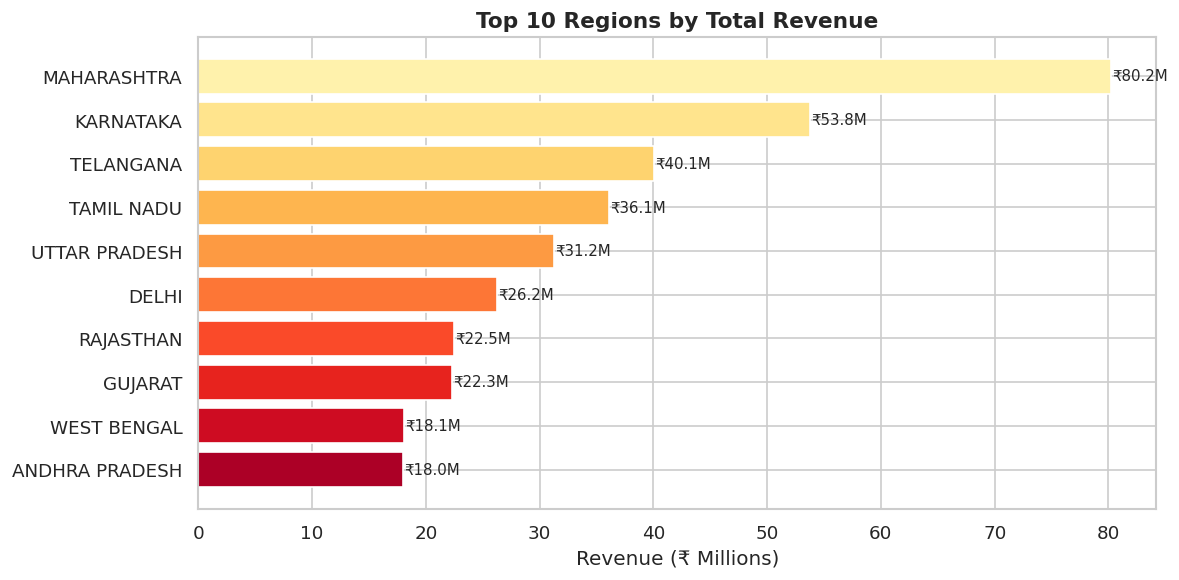

In [15]:
# ─── 2.6 Top 10 Regions by Revenue ───────────────────────────────────────────
top_regions = df.groupby('region')['revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_regions.index[::-1], top_regions.values[::-1]/1e6,
               color=sns.color_palette('YlOrRd', 10)[::-1])
ax.set_title('Top 10 Regions by Total Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (₹ Millions)')
for bar, val in zip(bars, top_regions.values[::-1]):
    ax.text(val/1e6 + 0.1, bar.get_y() + bar.get_height()/2,
            f'₹{val/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_artifacts/eda_regions.png', bbox_inches='tight')
plt.show()

---
## ⚙️ 3. Feature Engineering

In [16]:
# ─── 3.1 Encode Categorical Variables ────────────────────────────────────────
df_model = df.copy()

# Label encode low-cardinality categoricals
label_encoders = {}
cat_cols = ['category', 'size', 'price_tier']

for col in cat_cols:
    le = LabelEncoder()
    df_model[f'{col}_enc'] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"  Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Region: group into tiers to reduce dimensionality
metro       = ['MAHARASHTRA', 'DELHI', 'KARNATAKA', 'TAMIL NADU', 'TELANGANA', 'WEST BENGAL']
tier1       = ['UTTAR PRADESH', 'GUJARAT', 'RAJASTHAN', 'ANDHRA PRADESH', 'HARYANA',
               'KERALA', 'MADHYA PRADESH', 'PUNJAB']

def region_tier(r):
    if r in metro: return 3
    elif r in tier1: return 2
    else: return 1

df_model['region_tier'] = df_model['region'].apply(region_tier)
print(f"\n  Region tier distribution:\n{df_model['region_tier'].value_counts().to_string()}")

  Encoded 'category': {'Blouse': 0, 'Ethnic Dress': 1, 'Kurta': 2, 'Set': 3, 'Skirt': 4, 'Top': 5, 'Western Dress': 6}
  Encoded 'size': {'L': 0, 'M': 1, 'S': 2, 'XL': 3, 'XS': 4, 'XXL': 5, 'XXXL': 6}
  Encoded 'price_tier': {'Budget': 0, 'Mid-range': 1, 'Premium': 2}

  Region tier distribution:
region_tier
3    60966
2    34310
1    18539


In [17]:
# ─── 3.2 Define Feature Matrix & Target ──────────────────────────────────────
FEATURES = [
    # Core price signals
    'price',
    'cost_price',
    'competitor_price',
    'price_diff',
    'price_ratio',
    # Discount signals
    'discount_pct',
    'is_discount',
    # Product features
    'category_enc',
    'size_enc',
    'price_tier_enc',
    # Time features
    'day_of_week',
    'month',
    'week_of_year',
    'quarter',
    'is_weekend',
    'is_festive_season',
    # Geographic
    'region_tier',
    # Margin
    'profit_margin_pct',
]

TARGET = 'quantity'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"✅ Feature matrix: {X.shape}")
print(f"   Features ({len(FEATURES)}): {FEATURES}")
print(f"   Target: {TARGET}")
print(f"\n   Target stats: min={y.min()}, max={y.max()}, mean={y.mean():.2f}, std={y.std():.2f}")

✅ Feature matrix: (113815, 18)
   Features (18): ['price', 'cost_price', 'competitor_price', 'price_diff', 'price_ratio', 'discount_pct', 'is_discount', 'category_enc', 'size_enc', 'price_tier_enc', 'day_of_week', 'month', 'week_of_year', 'quarter', 'is_weekend', 'is_festive_season', 'region_tier', 'profit_margin_pct']
   Target: quantity

   Target stats: min=1, max=20, mean=5.95, std=4.54


In [18]:
# ─── 3.3 Train/Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Train: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

Train: 91,052 rows (80%)
Test:  22,763 rows (20%)


---
## 🤖 4. Model Training & Comparison

In [19]:
# ─── 4.1 Define Models ────────────────────────────────────────────────────────
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.08,
        max_depth=6,
        subsample=0.8,
        random_state=42
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(
        n_estimators=200,
        learning_rate=0.08,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )

print(f"Models to train: {list(models.keys())}")

Models to train: ['Random Forest', 'Gradient Boosting', 'XGBoost']


In [20]:
# ─── 4.2 Train & Evaluate All Models ─────────────────────────────────────────
results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 1, 20)  # clip to valid demand range

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape, 'model': model}
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.6f}")
    print(f"  MAPE: {mape:.2f}%")

print("\n✅ All models trained.")


🔄 Training Random Forest...
  MAE:  0.5966
  RMSE: 0.8337
  R²:   0.966942
  MAPE: 12.22%

🔄 Training Gradient Boosting...
  MAE:  0.5107
  RMSE: 0.6873
  R²:   0.977534
  MAPE: 10.71%

🔄 Training XGBoost...
  MAE:  0.5109
  RMSE: 0.6894
  R²:   0.977395
  MAPE: 10.64%

✅ All models trained.


📊 Model Comparison:
                      MAE    RMSE      R2     MAPE
Random Forest      0.5966  0.8337  0.9669  12.2158
Gradient Boosting  0.5107  0.6873  0.9775  10.7064
XGBoost            0.5109  0.6894  0.9774  10.6434


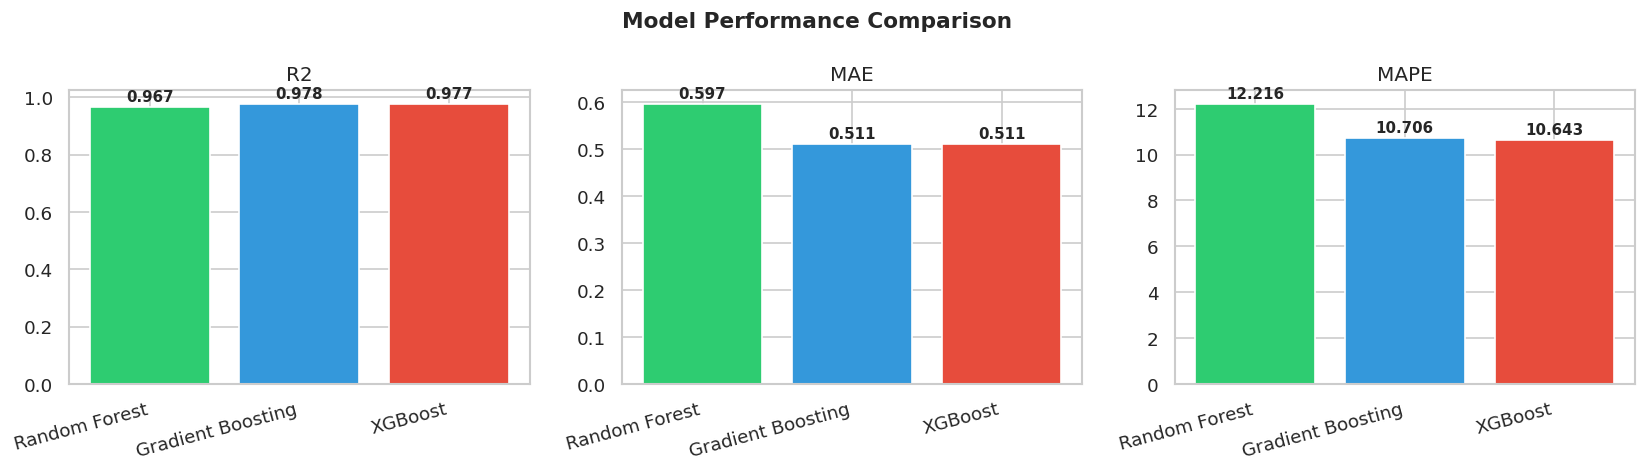

In [21]:
# ─── 4.3 Model Comparison Plot ───────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != 'model'}
    for name, vals in results.items()
}).T

print("📊 Model Comparison:")
print(metrics_df.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')

colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']
model_names = list(results.keys())

for ax, metric in zip(axes, ['R2', 'MAE', 'MAPE']):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors[:len(model_names)], edgecolor='white')
    ax.set_title(metric)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_artifacts/model_comparison.png', bbox_inches='tight')
plt.show()

In [22]:
# ─── 4.4 Select Best Model ────────────────────────────────────────────────────
best_name = max(results, key=lambda m: results[m]['R2'])
best_model = results[best_name]['model']

print(f"🏆 Best Model: {best_name}")
print(f"   R²:   {results[best_name]['R2']:.6f}")
print(f"   MAE:  {results[best_name]['MAE']:.4f}")
print(f"   MAPE: {results[best_name]['MAPE']:.2f}%")

🏆 Best Model: Gradient Boosting
   R²:   0.977534
   MAE:  0.5107
   MAPE: 10.71%


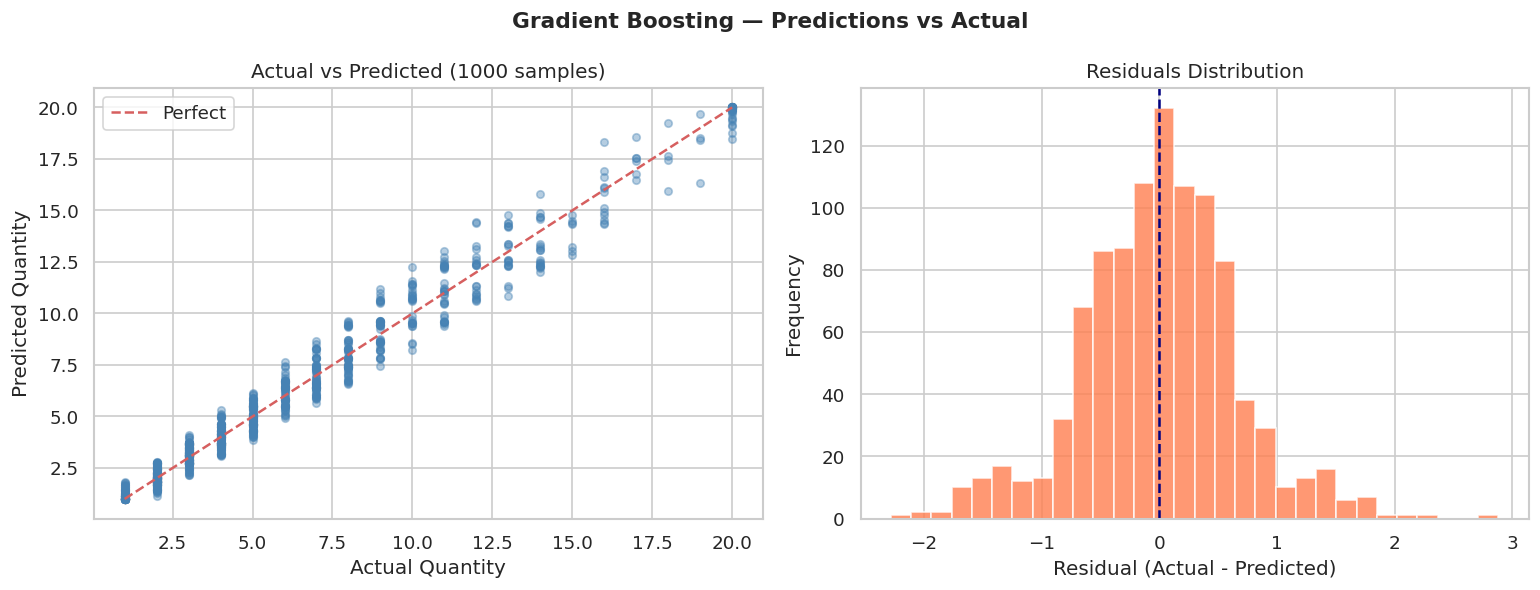

In [23]:
# ─── 4.5 Actual vs Predicted Plot ────────────────────────────────────────────
y_pred_best = np.clip(best_model.predict(X_test), 1, 20)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{best_name} — Predictions vs Actual', fontsize=13, fontweight='bold')

sample_idx = np.random.choice(len(y_test), 1000, replace=False)
axes[0].scatter(y_test.values[sample_idx], y_pred_best[sample_idx],
                alpha=0.4, s=20, color='steelblue')
min_val, max_val = y.min(), y.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect')
axes[0].set_title('Actual vs Predicted (1000 samples)')
axes[0].set_xlabel('Actual Quantity')
axes[0].set_ylabel('Predicted Quantity')
axes[0].legend()

residuals = y_test.values[:1000] - y_pred_best[:1000]
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='navy', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('model_artifacts/actual_vs_predicted.png', bbox_inches='tight')
plt.show()

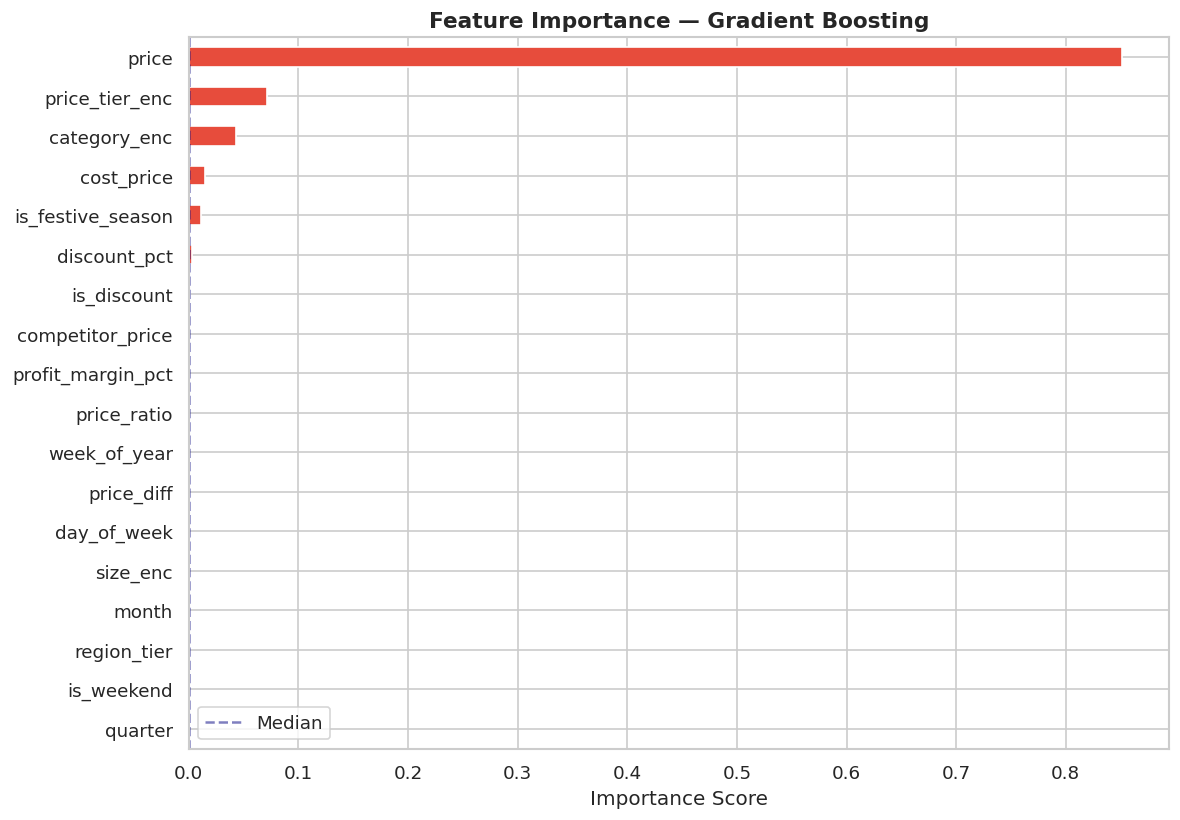


📊 Top 5 most important features:
price                0.8514
price_tier_enc       0.0717
category_enc         0.0435
cost_price           0.0149
is_festive_season    0.0115


In [24]:
# ─── 4.6 Feature Importance ──────────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importance_series = pd.Series(
        best_model.feature_importances_, index=FEATURES
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_fi = ['#e74c3c' if v > importance_series.median() else '#3498db'
                 for v in importance_series.values]
    importance_series.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
    ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.axvline(importance_series.median(), color='navy', linestyle='--',
               alpha=0.5, label='Median')
    ax.legend()
    plt.tight_layout()
    plt.savefig('model_artifacts/feature_importance.png', bbox_inches='tight')
    plt.show()

    print("\n📊 Top 5 most important features:")
    print(importance_series.sort_values(ascending=False).head(5).round(4).to_string())

---
## 💡 5. Price Optimization Engine

In [25]:
# ─── 5.1 Core Optimizer Function ─────────────────────────────────────────────
def optimize_price(
    model,
    features: dict,
    cost_price: float,
    current_price: float,
    price_floor_pct: float = 0.70,
    price_ceil_pct:  float = 1.35,
    n_steps: int = 60,
    feature_names: list = FEATURES
) -> dict:
    """
    Simulates a range of prices and returns the price that maximises profit.

    Returns dict with:
      optimal_price, max_profit, price_range, profit_curve,
      demand_curve, current_demand, current_profit, improvement_pct
    """
    price_floor = max(cost_price * 1.05, current_price * price_floor_pct)
    price_ceil  = current_price * price_ceil_pct
    price_range = np.linspace(price_floor, price_ceil, n_steps)

    profit_curve = []
    demand_curve = []

    for p in price_range:
        row = features.copy()
        row['price']             = p
        row['price_diff']        = p - row.get('competitor_price', p)
        row['price_ratio']       = p / max(row.get('competitor_price', p), 1)
        row['profit_margin_pct'] = (p - cost_price) / p * 100

        X_sim = pd.DataFrame([row])[feature_names]
        demand = float(np.clip(model.predict(X_sim)[0], 1, 20))
        profit = (p - cost_price) * demand

        demand_curve.append(demand)
        profit_curve.append(profit)

    profit_arr = np.array(profit_curve)
    best_idx   = np.argmax(profit_arr)

    # Current metrics
    curr_row = features.copy()
    curr_row['price']             = current_price
    curr_row['price_diff']        = current_price - curr_row.get('competitor_price', current_price)
    curr_row['price_ratio']       = current_price / max(curr_row.get('competitor_price', current_price), 1)
    curr_row['profit_margin_pct'] = (current_price - cost_price) / current_price * 100
    X_curr = pd.DataFrame([curr_row])[feature_names]
    current_demand = float(np.clip(model.predict(X_curr)[0], 1, 20))
    current_profit = (current_price - cost_price) * current_demand

    optimal_price  = price_range[best_idx]
    max_profit     = profit_arr[best_idx]
    improvement    = (max_profit - current_profit) / max(abs(current_profit), 1) * 100

    return {
        'optimal_price':   round(optimal_price, 2),
        'max_profit':      round(max_profit, 2),
        'current_demand':  round(current_demand, 2),
        'current_profit':  round(current_profit, 2),
        'optimal_demand':  round(demand_curve[best_idx], 2),
        'improvement_pct': round(improvement, 2),
        'price_range':     price_range.tolist(),
        'profit_curve':    profit_arr.tolist(),
        'demand_curve':    demand_curve,
    }

print("✅ Optimizer function defined")

✅ Optimizer function defined


In [26]:
# ─── 5.2 Test Optimizer on Sample Row ────────────────────────────────────────
sample_row = X_test.iloc[0].to_dict()
sample_cost  = df_model['cost_price'].iloc[X_test.index[0]]
sample_price = df_model['price'].iloc[X_test.index[0]]

result = optimize_price(
    model        = best_model,
    features     = sample_row,
    cost_price   = sample_cost,
    current_price= sample_price
)

print("🎯 Optimization Result for Sample Product")
print(f"   Current Price:    ₹{sample_price:.2f}")
print(f"   Optimal Price:    ₹{result['optimal_price']:.2f}")
print(f"   Current Demand:   {result['current_demand']:.1f} units")
print(f"   Optimal Demand:   {result['optimal_demand']:.1f} units")
print(f"   Current Profit:   ₹{result['current_profit']:.2f}")
print(f"   Max Profit:       ₹{result['max_profit']:.2f}")
print(f"   Improvement:      +{result['improvement_pct']:.1f}%")

🎯 Optimization Result for Sample Product
   Current Price:    ₹799.00
   Optimal Price:    ₹1043.44
   Current Demand:   6.4 units
   Optimal Demand:   5.2 units
   Current Profit:   ₹1916.67
   Max Profit:       ₹2845.33
   Improvement:      +48.5%


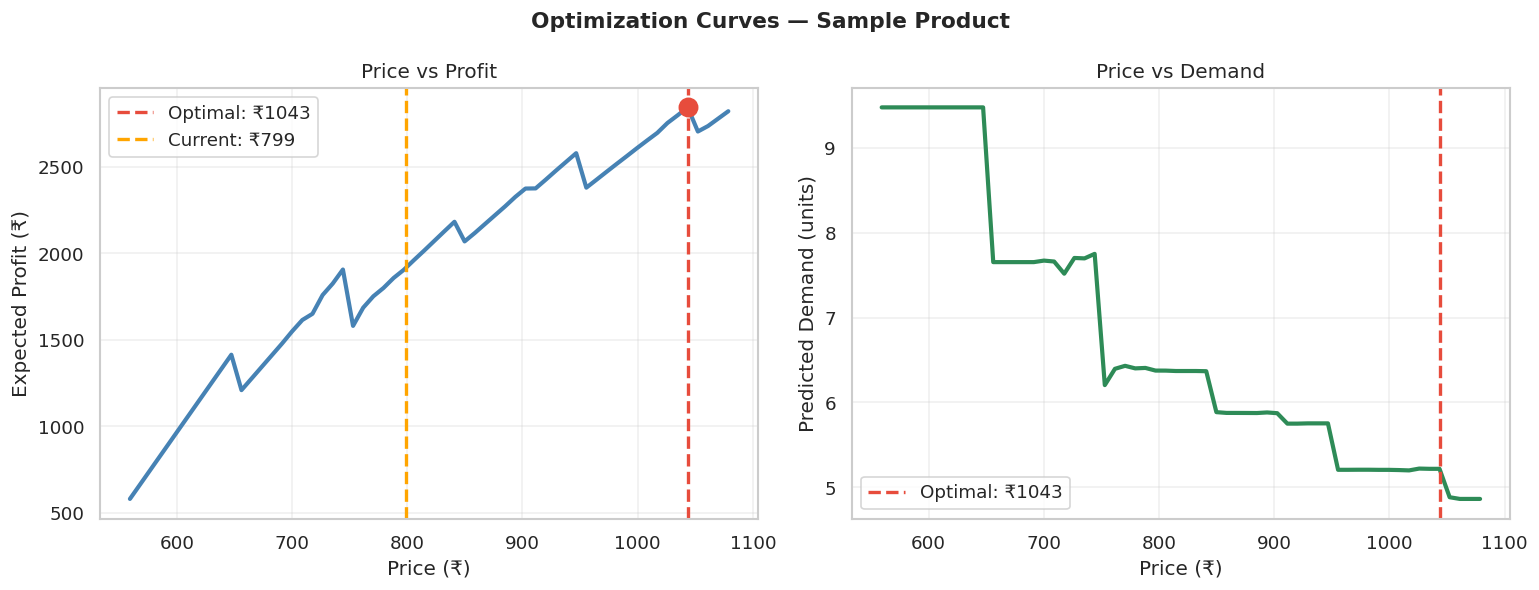

In [27]:
# ─── 5.3 Price vs Profit Curve ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Optimization Curves — Sample Product', fontsize=13, fontweight='bold')

axes[0].plot(result['price_range'], result['profit_curve'],
             color='steelblue', linewidth=2.5)
axes[0].axvline(result['optimal_price'], color='#e74c3c', linestyle='--', linewidth=2,
                label=f"Optimal: ₹{result['optimal_price']:.0f}")
axes[0].axvline(sample_price, color='orange', linestyle='--', linewidth=2,
                label=f"Current: ₹{sample_price:.0f}")
axes[0].scatter([result['optimal_price']], [result['max_profit']],
                color='#e74c3c', s=120, zorder=5)
axes[0].set_title('Price vs Profit')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Expected Profit (₹)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(result['price_range'], result['demand_curve'],
             color='seagreen', linewidth=2.5)
axes[1].axvline(result['optimal_price'], color='#e74c3c', linestyle='--', linewidth=2,
                label=f"Optimal: ₹{result['optimal_price']:.0f}")
axes[1].set_title('Price vs Demand')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Predicted Demand (units)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_artifacts/optimization_curves.png', bbox_inches='tight')
plt.show()

In [28]:
# ─── 5.4 Batch Optimization on 200 Products ──────────────────────────────────
batch_results = []

for i in range(min(200, len(X_test))):
    idx = X_test.index[i]
    row = X_test.iloc[i].to_dict()
    cost  = df_model['cost_price'].iloc[idx]
    price = df_model['price'].iloc[idx]

    opt = optimize_price(best_model, row, cost, price)
    batch_results.append({
        'product_id':    df_model['product_id'].iloc[idx],
        'category':      df_model['category'].iloc[idx],
        'current_price': price,
        'optimal_price': opt['optimal_price'],
        'price_change':  opt['optimal_price'] - price,
        'current_profit':opt['current_profit'],
        'max_profit':    opt['max_profit'],
        'improvement_pct': opt['improvement_pct'],
    })

batch_df = pd.DataFrame(batch_results)
print(f"\n✅ Batch optimization on {len(batch_df)} products")
print(f"   Avg profit improvement: +{batch_df['improvement_pct'].mean():.1f}%")
print(f"   Products needing price ↑: {(batch_df['price_change'] > 0).sum()}")
print(f"   Products needing price ↓: {(batch_df['price_change'] < 0).sum()}")
batch_df.head(5)


✅ Batch optimization on 200 products
   Avg profit improvement: +51.9%
   Products needing price ↑: 200
   Products needing price ↓: 0


,product_id,category,current_price,optimal_price,price_change,current_profit,max_profit,improvement_pct
0,JNE6973-KR-XL,Kurta,799,1043.44,244.44,1916.67,2845.33,48.45
1,TOP5864-TU-XXXL,Top,299,403.65,104.65,2154.60,4064.04,88.62
2,ETH5626-ED-L,Ethnic Dress,1499,1742.91,243.91,1005.21,1294.33,28.76
3,TOP4785-TU-M,Top,799,946.61,147.61,2219.00,2777.72,25.18
4,SET6982-ST-L,Set,1599,2158.65,559.65,866.57,1284.25,48.20


---
## 💾 6. Export All Artifacts

In [29]:
# ─── 6.1 Save Best Model ─────────────────────────────────────────────────────
joblib.dump(best_model, 'model_artifacts/demand_model.pkl')
print(f"✅ Model saved: model_artifacts/demand_model.pkl")

# Save all models
for name, info in results.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(info['model'], f'model_artifacts/{fname}.pkl')
    print(f"   Saved: {fname}.pkl")

✅ Model saved: model_artifacts/demand_model.pkl
   Saved: random_forest.pkl
   Saved: gradient_boosting.pkl
   Saved: xgboost.pkl


In [30]:
# ─── 6.2 Save Label Encoders ─────────────────────────────────────────────────
joblib.dump(label_encoders, 'model_artifacts/label_encoders.pkl')
print("✅ Label encoders saved: model_artifacts/label_encoders.pkl")

# Save encoder mappings as JSON for reference
encoder_map = {col: dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist()))
               for col, le in label_encoders.items()}
with open('model_artifacts/encoder_map.json', 'w') as f:
    json.dump(encoder_map, f, indent=2)
print("✅ Encoder map saved: model_artifacts/encoder_map.json")
print(json.dumps(encoder_map, indent=2))

✅ Label encoders saved: model_artifacts/label_encoders.pkl
✅ Encoder map saved: model_artifacts/encoder_map.json
{
  "category": {
    "Blouse": 0,
    "Ethnic Dress": 1,
    "Kurta": 2,
    "Set": 3,
    "Skirt": 4,
    "Top": 5,
    "Western Dress": 6
  },
  "size": {
    "L": 0,
    "M": 1,
    "S": 2,
    "XL": 3,
    "XS": 4,
    "XXL": 5,
    "XXXL": 6
  },
  "price_tier": {
    "Budget": 0,
    "Mid-range": 1,
    "Premium": 2
  }
}


In [31]:
# ─── 6.3 Save Feature Metadata ───────────────────────────────────────────────
metadata = {
    'best_model_name': best_name,
    'features': FEATURES,
    'target': TARGET,
    'model_performance': {
        name: {k: round(v, 6) for k, v in vals.items() if k != 'model'}
        for name, vals in results.items()
    },
    'categories': df['category'].unique().tolist(),
    'sizes': df['size'].unique().tolist(),
    'regions': df['region'].unique().tolist(),
    'price_range': {'min': float(df['price'].min()), 'max': float(df['price'].max())},
    'region_tiers': {
        'metro': metro,
        'tier1': tier1,
        'tier2_3': 'all others'
    }
}

with open('model_artifacts/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✅ Metadata saved: model_artifacts/metadata.json")

✅ Metadata saved: model_artifacts/metadata.json


In [32]:
# ─── 6.4 Save Batch Results ───────────────────────────────────────────────────
batch_df.to_csv('model_artifacts/batch_optimization_results.csv', index=False)
print("✅ Batch results saved: model_artifacts/batch_optimization_results.csv")

# Summary
print("\n" + "="*55)
print("🎉 PRICEORACLE ML PIPELINE COMPLETE")
print("="*55)
print("Saved artifacts:")
for f in sorted(os.listdir('model_artifacts')):
    size = os.path.getsize(f'model_artifacts/{f}')
    print(f"  📦 {f:<45} {size/1024:.1f} KB")
print()
print(f"Best model:   {best_name}")
print(f"R² Score:     {results[best_name]['R2']:.6f}")
print(f"MAE:          {results[best_name]['MAE']:.4f}")
print(f"""\n👉 Next: Run 'streamlit run priceoracle_app.py' to launch the app!""")

✅ Batch results saved: model_artifacts/batch_optimization_results.csv

🎉 PRICEORACLE ML PIPELINE COMPLETE
Saved artifacts:
  📦 actual_vs_predicted.png                       94.4 KB
  📦 batch_optimization_results.csv                14.1 KB
  📦 demand_model.pkl                              2302.5 KB
  📦 eda_category.png                              65.6 KB
  📦 eda_correlation.png                           112.9 KB
  📦 eda_distributions.png                         70.4 KB
  📦 eda_elasticity.png                            116.3 KB
  📦 eda_regions.png                               53.5 KB
  📦 eda_seasonal.png                              57.3 KB
  📦 encoder_map.json                              0.3 KB
  📦 feature_importance.png                        62.5 KB
  📦 gradient_boosting.pkl                         2302.5 KB
  📦 label_encoders.pkl                            1.2 KB
  📦 metadata.json                                 2.2 KB
  📦 model_comparison.png                          48.8 KB
  📦 